# VPINS — AIA Challenge: Xây dựng, thử nghiệm & tuning mô hình

**Nhiệm vụ 1:** từ 4.000 khách trong `test_data.txt`, chọn **top 800 ID** có khả năng mua AIA cao nhất. Chấm điểm = số người mua thật trong 800 ID → đây là **bài toán xếp hạng top-20%**.

**Cách làm trong notebook này** (gọi các hàm trong `src/`):
1. Nạp dữ liệu + feature engineering
2. Model zoo — chạy CV baseline (OOF) cho 10 mô hình
3. So sánh cách xử lý mất cân bằng (class weight / SMOTE / undersample)
4. Feature selection ("less is more")
5. **Tuning Optuna** cho 3 mô hình boosting mạnh nhất
6. **Ensemble** (rank-averaging + stacking)
7. Mô hình cuối → sinh `submission_800.txt`
8. SHAP — bắc cầu sang phần giải thích (Nhiệm vụ 2)

> Metric: **hits@20%** (số dương trong top 20% theo điểm) là chính; phụ là ROC-AUC & PR-AUC. Đánh giá bằng `RepeatedStratifiedKFold` (OOF) để trung thực; TargetEncoder fit theo từng fold để tránh rò rỉ.

## 1. Nạp dữ liệu, feature engineering & cấu hình

In [1]:
import warnings, os, sys, time
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
sys.path.insert(0, os.getcwd())

from src.data import load_data, TARGET, FEATURES, disp, NAME, A3
from src.features import build_features, feature_sets, make_preprocessor
from src.models import get_models
from src.cv import run_zoo, oof_proba, build_pipeline
from src.tune import tune_model, build_tuned_estimator
from src.ensemble import compare_ensembles, rank_average, to_rank, stack_oof
from src.predict import fit_full, score_test, make_submission, verify_submission
from src.metrics import summarize, topk_hits, lift_at_k

plt.rcParams["font.sans-serif"] = ["Segoe UI", "Arial", "Tahoma", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid")
FIG = Path("figures"); FIG.mkdir(exist_ok=True)
def savefig(n): plt.savefig(FIG / (n + ".png"), dpi=150, bbox_inches="tight")

# ---- Cấu hình ngân sách tuning (tăng để tối ưu sâu hơn) ----
N_TRIALS = {"LightGBM": 40, "XGBoost": 40, "CatBoost": 30}
N_REPEATS = 3      # số lần lặp CV cho OOF
SEED = 42
print("Cấu hình:", N_TRIALS, "| n_repeats =", N_REPEATS)

Cấu hình: {'LightGBM': 40, 'XGBoost': 40, 'CatBoost': 30} | n_repeats = 3


In [2]:
train, test = load_data()
Xtr, Xte, ENG = build_features(train, test)
y = train[TARGET].astype(int)
pos_rate = y.mean()
test_ids = test["ID"].values

SETS = feature_sets(ENG)
COLS = SETS["eng"]            # 85 gốc + đặc trưng tổng hợp
print(f"Train {Xtr.shape} | Test {Xte.shape} | tỉ lệ dương {pos_rate:.4f}")
print(f"Đặc trưng kỹ thuật thêm ({len(ENG)}):", ENG)
print(f"Bộ đặc trưng dùng chính 'eng': {len(COLS)} cột")

Train (5822, 100) | Test (4000, 99) | tỉ lệ dương 0.0598
Đặc trưng kỹ thuật thêm (13): ['agg_total_contrib', 'agg_total_number', 'agg_n_contrib_types', 'agg_n_number_types', 'agg_car_related', 'flag_co_xe', 'flag_chay_no', 'flag_nhan_tho', 'flag_tai_san', 'flag_tn_ca_nhan', 'flag_thuyen', 'ix_pp_x_car', 'ix_income_x_pp']
Bộ đặc trưng dùng chính 'eng': 98 cột


## 2. Model zoo — chạy CV baseline (OOF)

Chạy 10 mô hình với tham số mặc định hợp lý + xử lý mất cân bằng (class weight / scale_pos_weight). Xếp hạng theo **hits@20%** trên OOF.

In [3]:
models = get_models(pos_rate)
print("Đang chạy", len(models), "mô hình (mỗi mô hình", N_REPEATS, "x 5-fold)...\n")
t0 = time.time()
base_res, base_oof = run_zoo(models, Xtr, y, COLS, n_repeats=N_REPEATS, seed=SEED)
print(f"\nXong trong {time.time()-t0:.0f}s")
base_res[["AUC", "AP", "hits@20%", "hits@20%_std", "recall@20%", "lift@20%"]].round(4)

Đang chạy 10 mô hình (mỗi mô hình 3 x 5-fold)...



LogReg         AUC=0.7432  AP=0.1550  hits@20%=174 (±1.7)  lift=2.50


GaussianNB     AUC=0.6751  AP=0.1040  hits@20%=142 (±6.2)  lift=2.04


BernoulliNB    AUC=0.7287  AP=0.1512  hits@20%=175 (±2.2)  lift=2.51


LDA            AUC=0.7520  AP=0.1685  hits@20%=187 (±5.9)  lift=2.69


...

HistGB         AUC=0.7359  AP=0.1443  hits@20%=162 (±0.8)  lift=2.33


LightGBM       AUC=0.7445  AP=0.1435  hits@20%=160 (±4.8)  lift=2.30


XGBoost        AUC=0.7602  AP=0.1672  hits@20%=186 (±4.3)  lift=2.67


CatBoost       AUC=0.7645  AP=0.1714  hits@20%=187 (±4.3)  lift=2.69

Xong trong 84s


,AUC,AP,hits@20%,hits@20%_std,recall@20%,lift@20%
model,,,,,,
CatBoost,0.7645,0.1714,187,4.3205,0.5374,2.6854
LDA,0.7520,0.1685,187,5.8878,0.5374,2.6854
XGBoost,0.7602,0.1672,186,4.3205,0.5345,2.6710
BernoulliNB,0.7287,0.1512,175,2.1602,0.5029,2.5131
LogReg,0.7432,0.1550,174,1.6997,0.5000,2.4987
RandomForest,0.7470,0.1427,171,4.7140,0.4914,2.4556
HistGB,0.7359,0.1443,162,0.8165,0.4655,2.3264
ExtraTrees,0.7376,0.1373,161,2.9439,0.4626,2.3120
LightGBM,0.7445,0.1435,160,4.7842,0.4598,2.2977


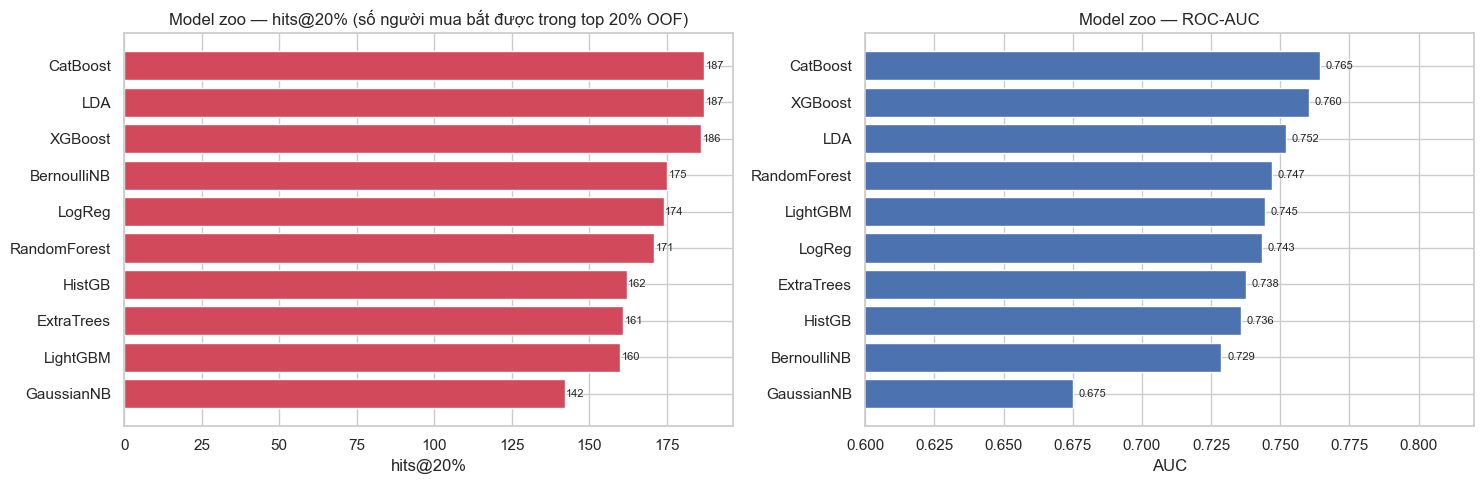

Top 3 theo hits@20%: ['CatBoost', 'LDA', 'XGBoost']


In [4]:
# Biểu đồ so sánh model zoo theo hits@20% và AUC
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
r = base_res.sort_values("hits@20%")
axes[0].barh(r.index, r["hits@20%"], color="#d1495b")
axes[0].set_title("Model zoo — hits@20% (số người mua bắt được trong top 20% OOF)")
axes[0].set_xlabel("hits@20%")
for i, v in enumerate(r["hits@20%"]): axes[0].text(v+0.5, i, int(v), va="center", fontsize=8)
r2 = base_res.sort_values("AUC")
axes[1].barh(r2.index, r2["AUC"], color="#4c72b0"); axes[1].set_xlim(0.6, 0.82)
axes[1].set_title("Model zoo — ROC-AUC"); axes[1].set_xlabel("AUC")
for i, v in enumerate(r2["AUC"]): axes[1].text(v+0.002, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout(); savefig("M01_model_zoo"); plt.show()
print("Top 3 theo hits@20%:", list(base_res.head(3).index))

## 3. So sánh cách xử lý mất cân bằng

Với cùng một mô hình (LightGBM), so sánh: (a) **class weight** (`scale_pos_weight`), (b) **SMOTE** (oversampling), (c) **RandomUnderSampler**, (d) **không xử lý**. Đo trên cùng OOF.

In [5]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from lightgbm import LGBMClassifier
from sklearn.base import clone

spw = (1 - pos_rate) / pos_rate
def lgbm(**kw): return LGBMClassifier(n_estimators=400, learning_rate=0.03, num_leaves=31,
                                      subsample=0.8, colsample_bytree=0.8, random_state=SEED,
                                      n_jobs=-1, verbose=-1, **kw)
def oof_imb(sampler, clf):
    pre = make_preprocessor(COLS, scale=False)
    steps = [("pre", pre)]
    if sampler is not None: steps.append(("samp", sampler))
    steps.append(("clf", clone(clf)))
    pipe = ImbPipeline(steps)
    oof = np.zeros(len(y))
    for r in range(N_REPEATS):
        skf = StratifiedKFold(5, shuffle=True, random_state=SEED+r)
        oof += cross_val_predict(pipe, Xtr, y, cv=skf, method="predict_proba", n_jobs=1)[:, 1]
    return oof / N_REPEATS

scen = {
 "Không xử lý":        (None, lgbm()),
 "scale_pos_weight":   (None, lgbm(scale_pos_weight=spw)),
 "SMOTE":              (SMOTE(random_state=SEED), lgbm()),
 "Undersample":        (RandomUnderSampler(random_state=SEED), lgbm()),
}
rows = []
for nm, (s, c) in scen.items():
    o = oof_imb(s, c); d = summarize(y, o); d["Cách xử lý"] = nm; rows.append(d)
imb_res = pd.DataFrame(rows).set_index("Cách xử lý").sort_values("hits@20%", ascending=False)
print(imb_res[["AUC", "AP", "hits@20%", "lift@20%"]].round(4))
print("\n=> Chọn cách xử lý tốt nhất cho boosting:", imb_res.index[0])

                     AUC      AP  hits@20%  lift@20%
Cách xử lý                                          
Không xử lý       0.7515  0.1453       178    2.5562
SMOTE             0.7541  0.1514       177    2.5418
Undersample       0.7595  0.1531       169    2.4269
scale_pos_weight  0.7468  0.1474       163    2.3407

=> Chọn cách xử lý tốt nhất cho boosting: Không xử lý


## 4. Feature selection — kiểm chứng "less is more"

CoIL 2000 cho thấy tập đặc trưng gọn nhiều khi cho kết quả tốt hơn. Ta xếp hạng bằng mutual information, rồi so OOF của mô hình tốt nhất trên: **raw (85)** vs **eng (đầy đủ)** vs **subset gọn**.

In [6]:
from sklearn.feature_selection import mutual_info_classif
Xenc = make_preprocessor(COLS, scale=False).fit_transform(Xtr, y)
mi = pd.Series(mutual_info_classif(Xenc, y, discrete_features=False, random_state=SEED),
               index=COLS).sort_values(ascending=False)

best_name = base_res.index[0]              # mô hình baseline tốt nhất
best_spec = models[best_name]
def oof_hits(cols):
    o, _ = oof_proba(best_spec, Xtr, y, cols, n_repeats=N_REPEATS, seed=SEED)
    return summarize(y, o)

cand = {"raw (85)": SETS["raw"], "eng (đầy đủ)": COLS}
for k in [20, 30, 40]:
    cand[f"top{k} MI"] = mi.head(k).index.tolist()
fs_rows = []
for nm, cs in cand.items():
    d = oof_hits(cs); d["Bộ đặc trưng"] = nm; d["n_cột"] = len(cs); fs_rows.append(d)
fs_res = pd.DataFrame(fs_rows).set_index("Bộ đặc trưng").sort_values("hits@20%", ascending=False)
print(f"Mô hình dùng để so: {best_name}")
print(fs_res[["n_cột", "AUC", "hits@20%", "lift@20%"]].round(4))
FINAL_COLS = SETS["eng"] if fs_res.index[0] == "eng (đầy đủ)" else cand[fs_res.index[0]]
print("\n=> Bộ đặc trưng chọn để tuning:", fs_res.index[0], f"({len(FINAL_COLS)} cột)")

Mô hình dùng để so: CatBoost
              n_cột     AUC  hits@20%  lift@20%
Bộ đặc trưng                                   
eng (đầy đủ)     98  0.7645       187    2.6854
top40 MI         40  0.7694       187    2.6854
raw (85)         85  0.7559       181    2.5992
top20 MI         20  0.7649       179    2.5705
top30 MI         30  0.7664       175    2.5131

=> Bộ đặc trưng chọn để tuning: eng (đầy đủ) (98 cột)


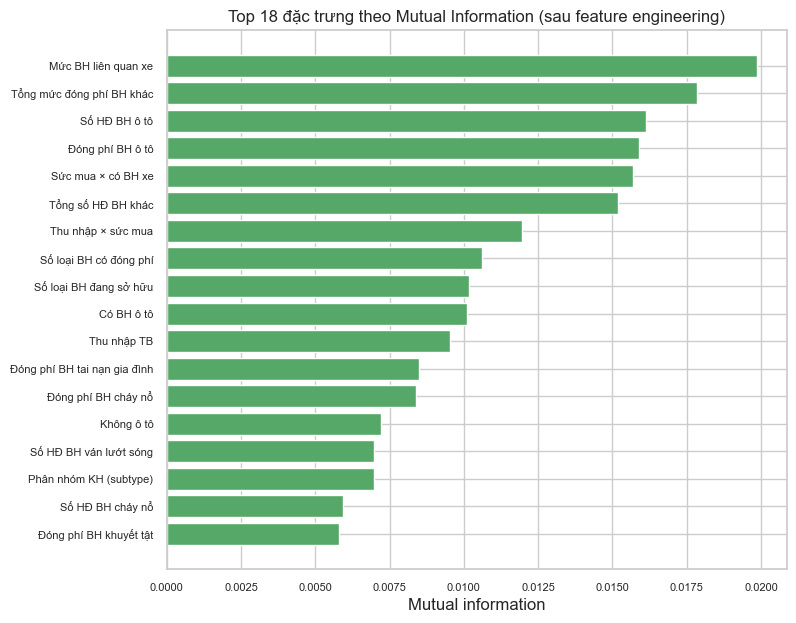

In [7]:
# Top đặc trưng theo mutual information (biểu đồ)
fig, ax = plt.subplots(figsize=(8, 7))
t = mi.head(18)[::-1]
ax.barh([disp(c) for c in t.index], t.values, color="#55a868")
ax.set_title("Top 18 đặc trưng theo Mutual Information (sau feature engineering)")
ax.set_xlabel("Mutual information"); ax.tick_params(labelsize=8)
savefig("M02_mutual_information"); plt.show()

## 5. Tuning siêu tham số bằng Optuna

Tuning 3 mô hình boosting (**LightGBM, XGBoost, CatBoost**) với objective = OOF `hits@20%`, dùng TPE sampler + MedianPruner và **early stopping** trong từng fold. Sau đó tính OOF của mô hình đã tune để so với baseline.

In [8]:
# ===== Tuning LightGBM =====
t0 = time.time()
bp_LightGBM, val_LightGBM, iter_LightGBM, study_LightGBM = tune_model(
    "LightGBM", Xtr, y, FINAL_COLS, pos_rate, n_trials=N_TRIALS["LightGBM"], n_splits=5, seed=SEED)
print(f"LightGBM: best OOF hits@20% = {val_LightGBM:.0f} | n_iter≈{iter_LightGBM} | {time.time()-t0:.0f}s")
print("Tham số tốt nhất:")
for k, v in bp_LightGBM.items():
    print(f"   {k}: {v}")

LightGBM: best OOF hits@20% = 191 | n_iter≈48 | 105s
Tham số tốt nhất:
   learning_rate: 0.0732661104856463
   num_leaves: 79
   max_depth: 6
   min_child_samples: 59
   subsample: 0.8009078428851363
   colsample_bytree: 0.9316754076154601
   reg_alpha: 5.025342526557803
   reg_lambda: 4.125027343477548
   scale_pos_weight: 1.0


In [9]:
# ===== Tuning XGBoost =====
t0 = time.time()
bp_XGBoost, val_XGBoost, iter_XGBoost, study_XGBoost = tune_model(
    "XGBoost", Xtr, y, FINAL_COLS, pos_rate, n_trials=N_TRIALS["XGBoost"], n_splits=5, seed=SEED)
print(f"XGBoost: best OOF hits@20% = {val_XGBoost:.0f} | n_iter≈{iter_XGBoost} | {time.time()-t0:.0f}s")
print("Tham số tốt nhất:")
for k, v in bp_XGBoost.items():
    print(f"   {k}: {v}")

XGBoost: best OOF hits@20% = 192 | n_iter≈31 | 46s
Tham số tốt nhất:
   learning_rate: 0.06999887706632602
   max_depth: 5
   min_child_weight: 9
   subsample: 0.6250715921029336
   colsample_bytree: 0.9411174695028565
   gamma: 0.038785459694982934
   reg_alpha: 0.02035302630744624
   reg_lambda: 0.08029091396360125
   scale_pos_weight: 3.9660919123831793


In [10]:
# ===== Tuning CatBoost =====
t0 = time.time()
bp_CatBoost, val_CatBoost, iter_CatBoost, study_CatBoost = tune_model(
    "CatBoost", Xtr, y, FINAL_COLS, pos_rate, n_trials=N_TRIALS["CatBoost"], n_splits=5, seed=SEED)
print(f"CatBoost: best OOF hits@20% = {val_CatBoost:.0f} | n_iter≈{iter_CatBoost} | {time.time()-t0:.0f}s")
print("Tham số tốt nhất:")
for k, v in bp_CatBoost.items():
    print(f"   {k}: {v}")

CatBoost: best OOF hits@20% = 194 | n_iter≈74 | 79s
Tham số tốt nhất:
   learning_rate: 0.034208840671982724
   depth: 5
   l2_leaf_reg: 19.335366602049405
   random_strength: 0.015425462558581291


In [11]:
# Tính OOF cho 3 mô hình đã tune (n_estimators cố định) -> thêm vào kho OOF
tuned_specs = {}
oof_dict = dict(base_oof)   # gồm cả baseline
for nm, bp, mi_ in [("LightGBM", bp_LightGBM, iter_LightGBM),
                    ("XGBoost",  bp_XGBoost,  iter_XGBoost),
                    ("CatBoost", bp_CatBoost, iter_CatBoost)]:
    est = build_tuned_estimator(nm, bp, mi_, pos_rate, seed=SEED)
    spec = {"est": est, "scale": False, "te": True}
    tuned_specs[nm + "*"] = spec
    o, _ = oof_proba(spec, Xtr, y, FINAL_COLS, n_repeats=N_REPEATS, seed=SEED)
    oof_dict[nm + "*"] = o
    s = summarize(y, o)
    print(f"{nm+'*':12s} (tuned)  AUC={s['AUC']:.4f}  hits@20%={s['hits@20%']:>3d}  lift={s['lift@20%']:.2f}")

# So sánh baseline vs tuned
cmp = []
for nm in ["LightGBM", "XGBoost", "CatBoost"]:
    cmp.append({"model": nm, "baseline hits@20%": summarize(y, oof_dict[nm])["hits@20%"],
                "tuned hits@20%": summarize(y, oof_dict[nm+"*"])["hits@20%"]})
pd.DataFrame(cmp).set_index("model")

LightGBM*    (tuned)  AUC=0.7710  hits@20%=182  lift=2.61


XGBoost*     (tuned)  AUC=0.7726  hits@20%=181  lift=2.60


CatBoost*    (tuned)  AUC=0.7782  hits@20%=192  lift=2.76


,baseline hits@20%,tuned hits@20%
model,,
LightGBM,160,182
XGBoost,186,181
CatBoost,187,192


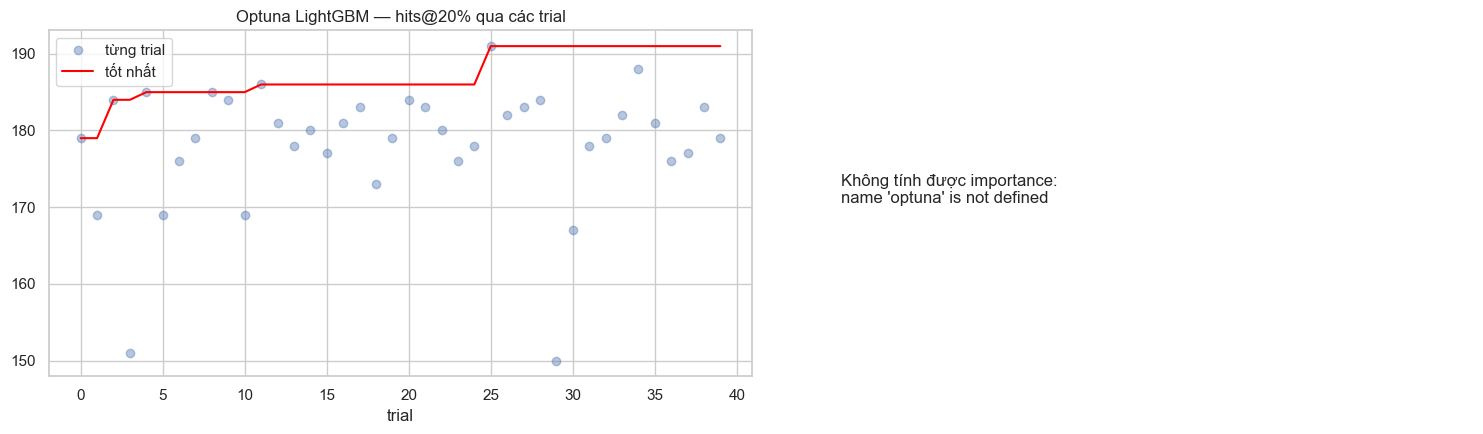

In [12]:
# Lịch sử tối ưu Optuna (LightGBM) + tầm quan trọng tham số
import optuna.visualization.matplotlib as ovm
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
vals = [t.value for t in study_LightGBM.trials if t.value is not None]
best_so_far = np.maximum.accumulate(vals)
axes[0].plot(vals, "o", alpha=.4, label="từng trial"); axes[0].plot(best_so_far, "-", color="red", label="tốt nhất")
axes[0].set_title("Optuna LightGBM — hits@20% qua các trial"); axes[0].set_xlabel("trial"); axes[0].legend()
try:
    imp = optuna.importance.get_param_importances(study_LightGBM)
    axes[1].barh(list(imp.keys())[::-1], list(imp.values())[::-1], color="#8172b3")
    axes[1].set_title("Tầm quan trọng tham số (LightGBM)")
except Exception as e:
    axes[1].text(0.1, 0.5, "Không tính được importance:\n"+str(e)[:60]); axes[1].axis("off")
plt.tight_layout(); savefig("M03_optuna_lightgbm"); plt.show()

## 6. Ensemble — rank-averaging & stacking

Kết hợp top mô hình (sau tune) để tăng độ ổn định cho xếp hạng. So sánh từng mô hình đơn vs **rank-average** vs **stacking (LR meta-learner)** trên OOF.

In [13]:
# Chọn 3-4 ứng viên tốt nhất trong toàn bộ kho OOF (baseline + tuned)
ranking = pd.Series({k: summarize(y, v)["hits@20%"] for k, v in oof_dict.items()}).sort_values(ascending=False)
print("Xếp hạng toàn bộ theo hits@20%:"); print(ranking.head(8))
TOP = ranking.head(3).index.tolist()
print("\nỨng viên ensemble:", TOP)

ens_res, ra_oof, st_oof = compare_ensembles(oof_dict, TOP, y)
print(); print(ens_res[["AUC", "AP", "hits@20%", "lift@20%"]].round(4))
FINAL = ens_res.index[0]
print("\n=> Phương án cuối (OOF tốt nhất):", FINAL)

Xếp hạng toàn bộ theo hits@20%:
CatBoost*      192
CatBoost       187
LDA            187
XGBoost        186
LightGBM*      182
XGBoost*       181
BernoulliNB    175
LogReg         174
dtype: int64

Ứng viên ensemble: ['CatBoost*', 'CatBoost', 'LDA']

                                      AUC      AP  hits@20%  lift@20%
combo                                                                
Rank-Avg (CatBoost*+CatBoost+LDA)  0.7802  0.1885       199    2.8577
Stacking-LR                        0.7807  0.1862       195    2.8003
CatBoost*                          0.7782  0.1831       192    2.7572
LDA                                0.7520  0.1685       187    2.6854
CatBoost                           0.7645  0.1714       187    2.6854

=> Phương án cuối (OOF tốt nhất): Rank-Avg (CatBoost*+CatBoost+LDA)


## 7. Mô hình cuối → sinh `submission_800.txt`

Refit phương án cuối trên **toàn bộ** 5.822 khách train, chấm điểm 4.000 khách test, lấy **top 800 ID**.

In [14]:
all_specs = {**models, **tuned_specs}
def refit_score(name):
    pipe = fit_full(all_specs[name], Xtr, y, FINAL_COLS)
    return score_test(pipe, Xte)

# Tạo điểm test theo phương án cuối
if FINAL.startswith("Rank-Avg"):
    member_scores = {n: refit_score(n) for n in TOP}
    test_score = np.mean([to_rank(member_scores[n]) for n in TOP], axis=0)
    print("Phương án: rank-average của", TOP)
elif FINAL == "Stacking-LR":
    from sklearn.linear_model import LogisticRegression
    M_oof = np.column_stack([oof_dict[n] for n in TOP])
    meta = LogisticRegression(max_iter=2000, class_weight="balanced").fit(M_oof, y)
    M_test = np.column_stack([refit_score(n) for n in TOP])
    test_score = meta.predict_proba(M_test)[:, 1]
    print("Phương án: stacking-LR trên", TOP)
else:
    test_score = refit_score(FINAL)
    print("Phương án: mô hình đơn", FINAL)

top800, full = make_submission(test_score, test_ids, k=800,
                               out_path="submission_800.txt", full_csv="outputs/test_scores.csv")
ok, ids = verify_submission("submission_800.txt")
print("Kiểm tra file nộp:", ok)
print("5 ID điểm cao nhất:", top800["ID"].head().tolist())

Phương án: rank-average của ['CatBoost*', 'CatBoost', 'LDA']
Kiểm tra file nộp: {'đủ k dòng': True, 'ID duy nhất': True, 'trong [1,4000]': True}
5 ID điểm cao nhất: [1996, 2844, 1243, 166, 948]


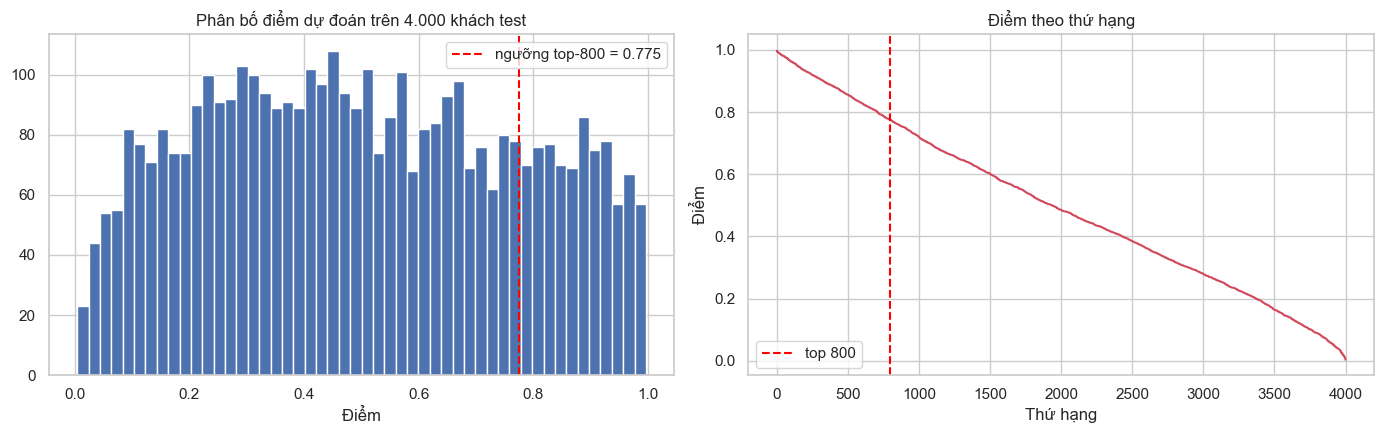

Kỳ vọng (theo OOF): lift@20% ≈ 2.86x, tức trong 800 khách chọn có ~137 người mua (so với ~48 nếu chọn ngẫu nhiên).


In [15]:
# Phân bố điểm test + ngưỡng top-800
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(full["score"], bins=50, color="#4c72b0", edgecolor="white")
thr = full.iloc[799]["score"]
axes[0].axvline(thr, color="red", ls="--", label=f"ngưỡng top-800 = {thr:.3f}")
axes[0].set_title("Phân bố điểm dự đoán trên 4.000 khách test"); axes[0].set_xlabel("Điểm"); axes[0].legend()
axes[1].plot(full["rank"], np.cumsum(np.ones(len(full)))/np.arange(1, len(full)+1), alpha=0)  # placeholder
sorted_score = full["score"].values
axes[1].plot(full["rank"], sorted_score, color="#d1495b")
axes[1].axvline(800, color="red", ls="--", label="top 800")
axes[1].set_title("Điểm theo thứ hạng"); axes[1].set_xlabel("Thứ hạng"); axes[1].set_ylabel("Điểm"); axes[1].legend()
plt.tight_layout(); savefig("M04_test_score_dist"); plt.show()
exp_oof = summarize(y, oof_dict[TOP[0]] if FINAL not in ("Stacking-LR",) and not FINAL.startswith("Rank-Avg") else ra_oof)
print(f"Kỳ vọng (theo OOF): lift@20% ≈ {ens_res.iloc[0]['lift@20%']:.2f}x, "
      f"tức trong 800 khách chọn có ~{ens_res.iloc[0]['lift@20%']*pos_rate*800:.0f} người mua "
      f"(so với ~{pos_rate*800:.0f} nếu chọn ngẫu nhiên).")

## 8. Giải thích mô hình (SHAP) — bắc cầu Nhiệm vụ 2

Dùng SHAP trên mô hình boosting tốt nhất để chỉ ra đặc trưng nào đẩy xác suất mua AIA — đầu vào cho phần giải thích & khuyến nghị chiến dịch.

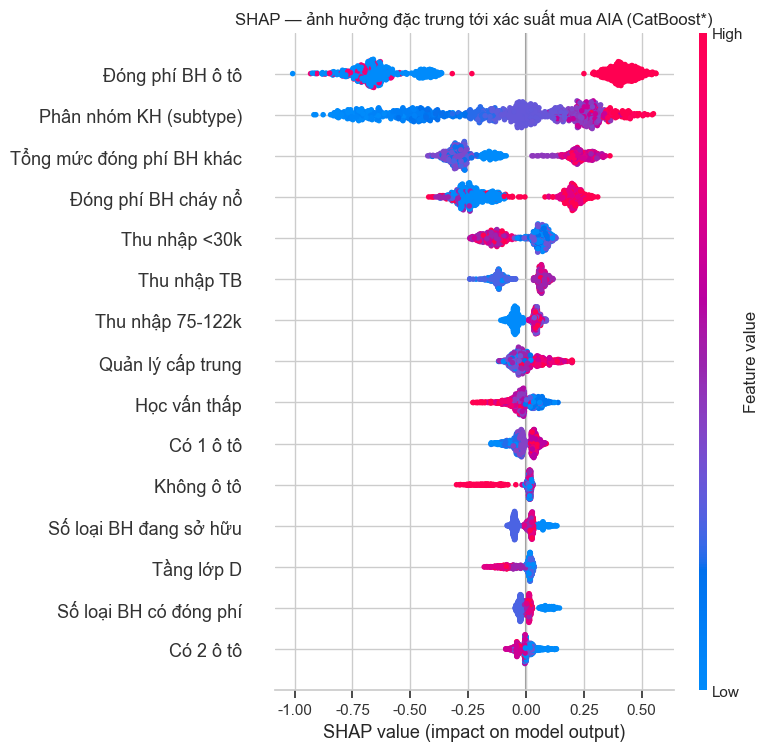

Đã vẽ SHAP cho CatBoost*


In [16]:
# Chọn 1 mô hình cây tốt nhất đã refit để giải thích bằng SHAP
tree_candidates = [n for n in TOP if n.rstrip("*") in ("LightGBM", "XGBoost", "CatBoost", "RandomForest", "ExtraTrees", "HistGB")]
expl_name = tree_candidates[0] if tree_candidates else "LightGBM*"
pre = make_preprocessor(FINAL_COLS, scale=False).fit(Xtr, y)
Xtr_enc = pre.transform(Xtr)
feat_names = [disp(c) for c in FINAL_COLS]
from sklearn.base import clone
clf = clone(all_specs[expl_name]["est"]).fit(Xtr_enc, y)
try:
    import shap
    samp_idx = np.random.RandomState(0).choice(len(Xtr), 1000, replace=False)
    expl = shap.TreeExplainer(clf)
    sv = expl.shap_values(Xtr_enc[samp_idx])
    sv1 = sv[1] if isinstance(sv, list) else sv
    shap.summary_plot(sv1, Xtr_enc[samp_idx], feature_names=feat_names, show=False, max_display=15)
    plt.title(f"SHAP — ảnh hưởng đặc trưng tới xác suất mua AIA ({expl_name})")
    savefig("M05_shap_summary"); plt.show()
    print("Đã vẽ SHAP cho", expl_name)
except Exception as e:
    print("SHAP lỗi/không sẵn:", type(e).__name__, str(e)[:120])

## 9. Tổng kết

Bảng so sánh tổng hợp + danh sách output. Các con số dưới đây là **OOF trên train** (proxy trung thực cho hiệu quả trên test).

In [17]:
print("="*66); print("TỔNG KẾT MÔ HÌNH — VPINS AIA CHALLENGE"); print("="*66)
print(f"Train {len(y)} KH | Test {len(test_ids)} KH | tỉ lệ mua {pos_rate*100:.2f}%")
print(f"Bộ đặc trưng: {len(FINAL_COLS)} cột | Phương án cuối: {FINAL}")
print(f"OOF phương án cuối: AUC={ens_res.iloc[0]['AUC']:.4f}, "
      f"hits@20%={int(ens_res.iloc[0]['hits@20%'])}/{int(y.sum())}, "
      f"lift@20%={ens_res.iloc[0]['lift@20%']:.2f}x")
print("\nFile kết quả:")
print("  - submission_800.txt        (800 ID nộp bài)")
print("  - outputs/test_scores.csv   (điểm + thứ hạng toàn bộ 4.000 khách)")
print("\nBiểu đồ (figures/): M01..M05 + EDA cũ. Dùng cho slide trình bày.")
base_res[["AUC", "hits@20%", "lift@20%"]].round(4)

TỔNG KẾT MÔ HÌNH — VPINS AIA CHALLENGE
Train 5822 KH | Test 4000 KH | tỉ lệ mua 5.98%
Bộ đặc trưng: 98 cột | Phương án cuối: Rank-Avg (CatBoost*+CatBoost+LDA)
OOF phương án cuối: AUC=0.7802, hits@20%=199/348, lift@20%=2.86x

File kết quả:
  - submission_800.txt        (800 ID nộp bài)
  - outputs/test_scores.csv   (điểm + thứ hạng toàn bộ 4.000 khách)

Biểu đồ (figures/): M01..M05 + EDA cũ. Dùng cho slide trình bày.


,AUC,hits@20%,lift@20%
model,,,
CatBoost,0.7645,187,2.6854
LDA,0.7520,187,2.6854
XGBoost,0.7602,186,2.6710
BernoulliNB,0.7287,175,2.5131
LogReg,0.7432,174,2.4987
RandomForest,0.7470,171,2.4556
HistGB,0.7359,162,2.3264
ExtraTrees,0.7376,161,2.3120
LightGBM,0.7445,160,2.2977
